<a href="https://colab.research.google.com/github/purnimamarasinghe2005-lgtm/BI-and-Data-Mining/blob/main/diabetes_readmission_project__(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Early Readmission of Diabetic Patients: A Business Intelligence Analysis of 130 US Hospitals (1999–2008)

**Module:** Business Intelligence and Data Mining (UFCFMM)  
**Assessment:** Task 2 – Group Project Portfolio  
**Datasets:** **[diabetic_data.csv](https://drive.google.com/file/d/19ZaXM0NpKTD1bQaxtgKqyZR28tH6wRcq/view?usp=drive_link)** and **[IDS_mapping.csv](https://drive.google.com/file/d/1J3bVU-mJaJas84V4LqSuFhhBI21U9_NY/view?usp=drive_link)**


This notebook studies whether hospital encounter data can help identify diabetic patients who are likely to be readmitted within 30 days. Readmission matters from a business perspective because it affects cost, bed capacity, and quality of care. The notebook follows the full business intelligence lifecycle required in the brief: problem definition, dataset justification, preprocessing, exploratory analysis, modelling, evaluation, recommendations, and ethical reflection. The dataset is associated with the study by Strack *et al.* (2014), which supports its academic relevance.


## Business Problem and Objectives

Hospitals want to reduce avoidable readmissions because repeated admissions increase operational pressure and may signal weak discharge planning. For diabetic patients this problem is particularly important because care is often long term and medication intensive. Business intelligence can support the issue by turning historical encounter data into actionable risk insight (Raghupathi and Raghupathi, 2014).

The objective of this project is to predict early readmission within 30 days and translate the results into practical hospital recommendations. More specifically, the notebook aims to understand the data, identify key patterns, prepare the dataset for modelling, compare classification models, and interpret the final results in a way that supports discharge planning and patient prioritisation.


This framing keeps the work aligned with the module expectation that technical analysis should answer a real organisational problem rather than a purely abstract modelling task.

## Dataset Overview and Justification

Two datasets are used.

>**[diabetic_data.csv](https://drive.google.com/file/d/19ZaXM0NpKTD1bQaxtgKqyZR28tH6wRcq/view?usp=drive_link)** is the main analytical file. It contains 101,766 diabetic hospital encounters from 130 US hospitals between 1999 and 2008. It includes demographics, admission details, utilisation history, medication-related variables, and the `readmitted` outcome. This file is used for cleaning, visualisation, feature engineering, and modelling.

>**[IDS_mapping.csv](https://drive.google.com/file/d/1J3bVU-mJaJas84V4LqSuFhhBI21U9_NY/view?usp=drive_link)** is a lookup file that explains coded identifiers such as admission type, discharge disposition, and admission source. It is not the main modelling table, but it is still important because it improves interpretation of coded fields and shows that both source files were considered.

The dataset is appropriate because it directly contains the business outcome of interest and provides enough size and feature variety for meaningful analysis (Strack *et al*., 2014).


This combination of a main analytical table and a supporting mapping file is also methodologically stronger than using the encounter file alone, because it demonstrates attention to source documentation and field meaning.

## Initial File Validation

These first cells confirm that both files can be loaded and give a quick structural check before the main workflow starts.

In [ ]:
import pandas as pd

# Load the datasets
df = pd.read_csv("diabetic_data.csv")
mapping = pd.read_csv("IDS_mapping.csv")

# Display dataset dimensions
print("Diabetic dataset shape:", df.shape)

# Preview first rows
df.head()

Diabetic dataset shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


`info()` is used here to inspect data types and non-null counts. This helps identify likely cleaning needs early.

In [ ]:
# Basic dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

This first missing-value check provides a quick audit of raw data quality.

In [ ]:
# Check missing values
df.isnull().sum().sort_values(ascending=False).head(10)

,0
max_glu_serum,96420
A1Cresult,84748
race,0
gender,0
age,0
weight,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0


## Data Loading and Initial Inspection

The next section restarts the workflow in a clearer top-to-bottom order so the notebook reads like a complete report.

### Library Import and Analytical Setup

These packages support the full workflow: data handling, numerical operations, and visualisation.

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

### Dataset Loading

This cell begins the formal analysis sequence and ensures later steps start from the original source files.

In [ ]:
# Load datasets
df = pd.read_csv("diabetic_data.csv")
mapping = pd.read_csv("IDS_mapping.csv")

# Display dataset dimensions
print("Dataset Shape:", df.shape)

Dataset Shape: (101766, 50)


### Why a preview is shown

`head()` is used to inspect sample rows, verify field names, and spot obvious coded values such as `?`.

In [ ]:
# Display first 5 rows
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


The sample rows confirm that each record represents one hospital encounter and that the table mixes demographic, utilisation, and treatment variables.

### Schema Inspection

The schema is printed so the later feature-selection decisions are transparent.

In [ ]:
# Show column names
df.columns

Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')

### Why `info()` is repeated

This fuller structural check supports later decisions about encoding, scaling, and missing-value handling.

In [ ]:
# Check dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

The dataset contains both categorical and numerical variables. This distinction matters because they require different preprocessing steps (James *et al*., 2021).

### Data Integrity Check

A duplicated encounter ID would suggest a data integrity issue that could affect counts and modelling.

In [ ]:
# Check duplicate encounter IDs
df['encounter_id'].duplicated().sum()

np.int64(0)

### Encounter-Level Structure

This confirms whether the dataset is encounter-based or patient-based.

In [ ]:
print("Unique patients:", df['patient_nbr'].nunique())
print("Total encounters:", df['encounter_id'].nunique())

Unique patients: 71518
Total encounters: 101766


The dataset contains more encounters than unique patients, so some patients appear multiple times. This supports the use of prior-utilisation features.

## Data Cleaning and Preprocessing

This section standardises missing values, removes fields that are unsuitable for modelling, and creates a target variable aligned with the business problem.

### Handling Non-Standard Missing Values

Some missing values are stored as `?`. They must be converted to proper null values so pandas can recognise them.

In [ ]:
# Replace special missing value symbols with NaN
df = df.replace("?", np.nan)

# Check missing values
df.isnull().sum().sort_values(ascending=False).head(15)

,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
patient_nbr,0


### Missing Data Assessment

Percentages show how serious the missingness is relative to the full dataset and support justified column removal.

In [ ]:
# Calculate percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent.sort_values(ascending=False).head(15)

,0
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208
payer_code,39.557416
race,2.233555
diag_3,1.398306
diag_2,0.351787
diag_1,0.020636
patient_nbr,0.000000


Columns with very high missingness are weaker candidates for reliable analysis unless strong imputation is justified.

### Removal of High-Missingness Variables

`weight`, `payer_code`, and `medical_specialty` contain substantial missing data, so they are removed to reduce noise.

In [ ]:
# Drop columns with very high missing values
df = df.drop(columns=['weight','payer_code','medical_specialty'])

This decision favours data quality and model stability over keeping every raw variable.

### Exclusion of Identifier Fields
Identifiers distinguish records, but they do not represent generalisable behaviour and may mislead the model.

In [ ]:
# Remove identifier variables
df = df.drop(columns=['encounter_id','patient_nbr'])

Removing identifiers keeps the feature set focused on meaningful encounter information.

### Target Variable Transformation

The project focuses on **early** readmission, so the original categories are simplified into a yes/no outcome.

In [ ]:
# Create binary readmission variable
df['readmitted_binary'] = df['readmitted'].apply(lambda x: 1 if x == '<30' else 0)

# Check class distribution
df['readmitted_binary'].value_counts()

,count
readmitted_binary,
0,90409
1,11357


`<30` is coded as 1 because it is the risk event of interest. `>30` and `NO` are grouped as 0.

### Why `X` and `y` are created

Predictors and outcome are separated so the data is ready for machine learning.

In [ ]:
# Define features and target variable
X = df.drop(columns=['readmitted','readmitted_binary'])
y = df['readmitted_binary']

print("Feature matrix shape:", X.shape)
print("Target variable shape:", y.shape)

Feature matrix shape: (101766, 44)
Target variable shape: (101766,)


The cleaned dataset is now ready for EDA and model development.

## Exploratory Data Analysis (EDA)

EDA is used to understand distributions, compare groups, and identify variables that may help explain readmission. Each chart includes a brief note on why that chart style is suitable. Simple visuals are chosen because they communicate patterns clearly without unnecessary design clutter (Few, 2012).

The purpose of EDA here is not only descriptive. It also supports later modelling choices by showing which variables appear informative, whether class imbalance is present, and which chart forms communicate those patterns most clearly to a non-technical reader.

### Chart 1: Age group vs readmission rate


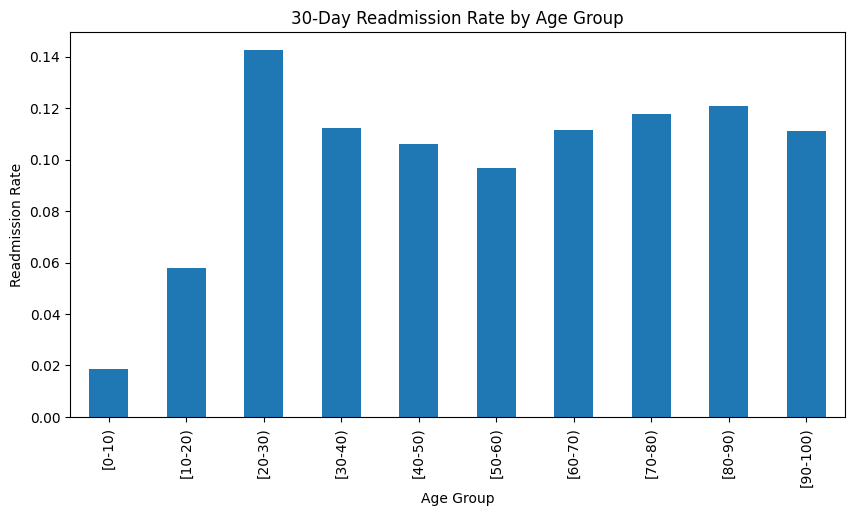

In [ ]:
age_readmit = df.groupby('age')['readmitted_binary'].mean().sort_index()

plt.figure(figsize=(10,5))
age_readmit.plot(kind='bar')
plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate")
plt.show()

**Chart purpose:**  
This visualisation is used to examine whether patient age is associated with the probability of early readmission.

**Why this chart type was chosen:**  
A bar chart is suitable because age is recorded in ordered categorical bands and the aim is to compare the average readmission rate across these groups in a clear and interpretable way.

**Interpretation:**  
The chart suggests that readmission rates tend to increase among older age groups. In particular, patients in the older age categories appear more likely to experience readmission within 30 days of discharge.

**Business relevance:**  
This finding suggests that older diabetic patients may require more intensive discharge planning, medication support, and follow-up care. Hospitals could use this insight to prioritise elderly patients for additional post-discharge monitoring, which may help reduce avoidable readmissions (Strack et al., 2014).

### Chart 2: Gender vs readmission rate



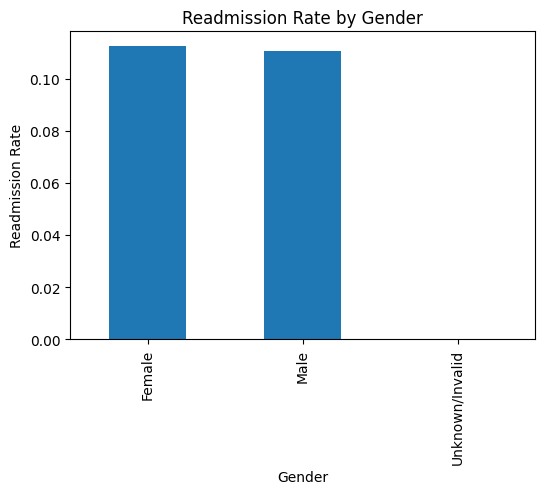

In [ ]:
gender_readmit = df.groupby('gender')['readmitted_binary'].mean()

plt.figure(figsize=(6,4))
gender_readmit.plot(kind='bar')
plt.title("Readmission Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Readmission Rate")
plt.show()

**Chart purpose:**  
This visualisation examines whether patient gender is associated with the likelihood of early hospital readmission within 30 days.

**Why this chart type was chosen:**  
A bar chart is appropriate because gender is a categorical variable and the objective is to compare the average readmission rate across different groups. This chart type clearly presents differences in group-level proportions and supports straightforward interpretation.

**Interpretation:**  
The chart indicates that the readmission rates for male and female patients are relatively similar, with only minor variation between the groups. This suggests that gender alone may not be a strong predictor of early readmission compared to other factors such as age, treatment complexity, or previous hospital utilisation.

**Business relevance:**  
From a hospital management perspective, this finding implies that discharge planning strategies should not rely heavily on gender-based risk assumptions. Instead, healthcare providers should focus on more influential clinical and operational indicators when prioritising patients for follow-up care and support interventions.

### Chart 3: Previous inpatient visits vs readmission.

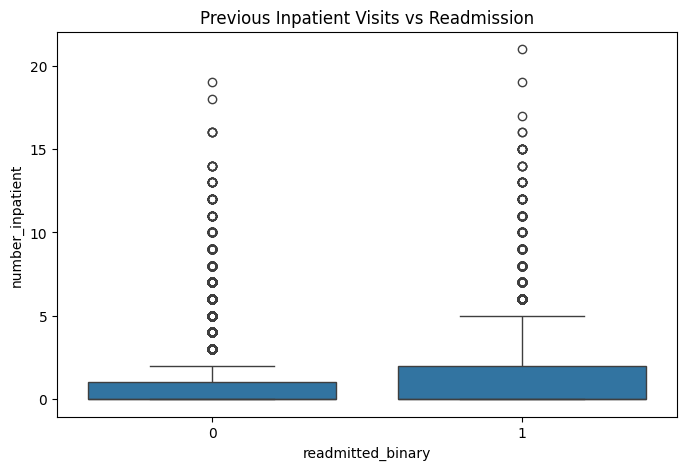

In [ ]:
prev_visits = df[['number_outpatient','number_emergency','number_inpatient','readmitted_binary']]

plt.figure(figsize=(8,5))
sns.boxplot(x='readmitted_binary', y='number_inpatient', data=df)
plt.title("Previous Inpatient Visits vs Readmission")
plt.show()

**Chart purpose:**  
This visualisation is used to examine whether a patient’s prior inpatient hospital use is related to the likelihood of early readmission.

**Why this chart type was chosen:**  
A boxplot is suitable because the number of previous inpatient visits is a numerical count variable that may contain skewness and outliers. The boxplot allows the distribution of prior utilisation to be compared clearly across the two readmission groups.

**Interpretation:**  
The chart suggests that patients who were readmitted within 30 days tend to have a higher number of previous inpatient visits. This indicates that repeated prior admissions may be an important warning sign of future readmission risk.

**Business relevance:**  
Historical inpatient utilisation is highly relevant for hospital decision-making because it helps identify patients with unstable health conditions or repeated care needs. Hospitals could use this insight to prioritise patients with frequent prior admissions for targeted discharge planning and chronic care support.

### Chart 4: Number of medications vs readmission

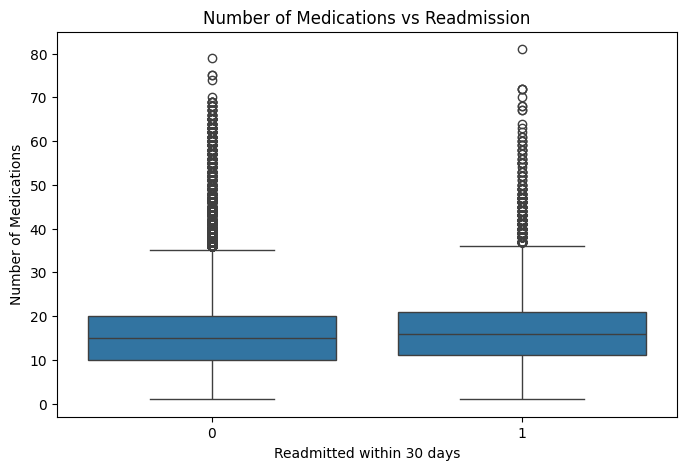

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(x='readmitted_binary', y='num_medications', data=df)
plt.title("Number of Medications vs Readmission")
plt.xlabel("Readmitted within 30 days")
plt.ylabel("Number of Medications")
plt.show()

**Chart purpose:**  
This chart examines whether treatment complexity, measured by the number of medications prescribed during the hospital encounter, is associated with early readmission risk.

**Why this chart type was chosen:**  
A boxplot is appropriate because the number of medications is a numerical variable with a potentially skewed distribution. The boxplot allows comparison of median values, spread, and extreme observations between readmitted and non-readmitted patients.

**Interpretation:**  
The chart shows that the median number of medications is slightly higher for patients who were readmitted within 30 days. The readmitted group also displays greater variability, suggesting that more complex treatment patterns may be linked to higher readmission risk.

**Business relevance:**  
This finding indicates that medication complexity could be considered during discharge planning. Hospitals may reduce readmission risk by providing medication counselling, pharmacist review, and clearer treatment guidance for patients receiving multiple medications.

### Chart 5: Correlation heatmap

A **heatmap** is useful when several numerical variables must be compared together in one compact view.

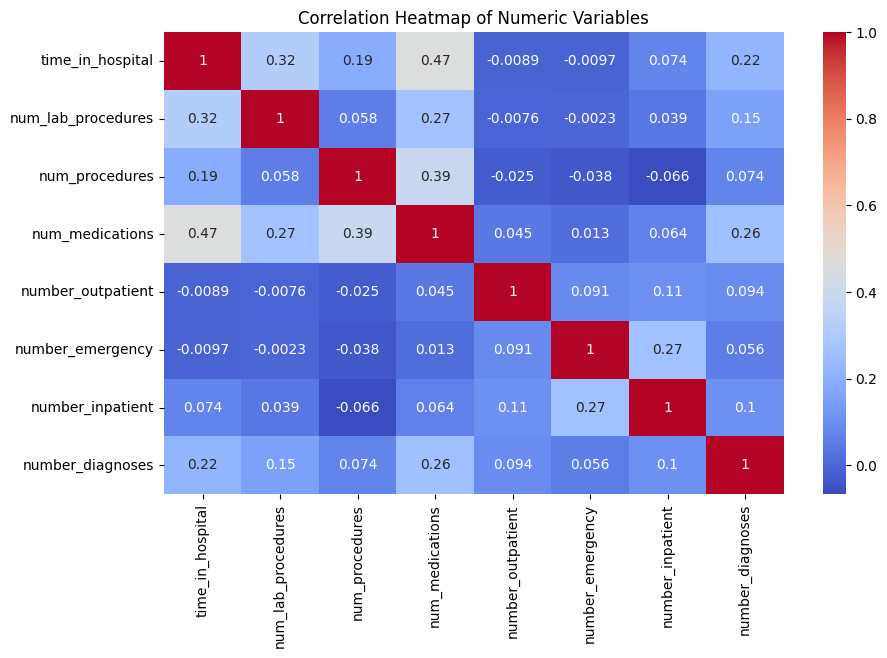

In [ ]:
numeric_cols = [
'time_in_hospital',
'num_lab_procedures',
'num_procedures',
'num_medications',
'number_outpatient',
'number_emergency',
'number_inpatient',
'number_diagnoses'
]

plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()



**Chart purpose:**  
This visualisation examines the strength and direction of relationships between key numerical variables in the dataset. Understanding these relationships helps identify whether variables provide unique information or represent similar underlying patterns in hospital utilisation and treatment intensity.

**Why this chart type was chosen:**  
A correlation heatmap is appropriate because it allows multiple numerical variables to be compared simultaneously in a compact and interpretable format. The colour gradient highlights the magnitude of relationships, while annotated coefficients provide precise statistical values. This supports efficient identification of variables that may influence model performance or indicate operational patterns.

**Interpretation:**  
The heatmap shows that most relationships between variables are weak to moderate rather than strongly correlated. For example, the number of medications has a moderate positive relationship with time spent in hospital and number of procedures, suggesting that patients receiving more intensive treatment tend to require longer stays. Similarly, moderate associations are observed between prior emergency and inpatient visits, indicating patterns of repeated healthcare utilisation.

However, the absence of very strong correlations suggests that these variables capture different dimensions of patient experience, such as treatment intensity, diagnostic complexity, and prior hospital use. This is beneficial for predictive modelling because it reduces the risk of redundancy and multicollinearity.

**Business relevance:**  
From a hospital management perspective, the results indicate that readmission risk is likely influenced by a combination of factors rather than a single dominant variable. Variables related to treatment intensity and prior utilisation may provide complementary signals for identifying high-risk patients. Therefore, decision-support systems should consider multiple operational indicators together when prioritising discharge planning and follow-up care.

## Feature Engineering

Feature engineering creates more useful predictors from the raw data and makes the business story clearer.

These engineered variables were chosen because they are easy to justify conceptually and easy to explain in a business report.

### Creation of Total Previous Hospital Visits


Combining outpatient, emergency, and inpatient counts gives one broader measure of prior healthcare use.

In [ ]:
# Create total previous hospital visits
df['total_previous_visits'] = (
    df['number_outpatient'] +
    df['number_emergency'] +
    df['number_inpatient']
)

df[['number_outpatient','number_emergency','number_inpatient','total_previous_visits']].head()

,number_outpatient,number_emergency,number_inpatient,total_previous_visits
0,0,0,0,0
1,0,0,0,0
2,2,0,1,3
3,0,0,0,0
4,0,0,0,0


The new feature summarises utilisation in a form that is easy to interpret and compare.

###Transformation of Age into Numeric Representation

The original age field is ordinal text. Midpoints preserve the ordering in a model-friendly format.

In [ ]:
# Convert age categories to numeric midpoints
age_mapping = {
    '[0-10)':5, '[10-20)':15, '[20-30)':25, '[30-40)':35,
    '[40-50)':45, '[50-60)':55, '[60-70)':65,
    '[70-80)':75, '[80-90)':85, '[90-100)':95
}

df['age_numeric'] = df['age'].map(age_mapping)

df[['age','age_numeric']].head()

,age,age_numeric
0,[0-10),5
1,[10-20),15
2,[20-30),25
3,[30-40),35
4,[40-50),45


This provides an approximate age scale without claiming exact ages for individual patients.

### Development of a High Healthcare Utilisation Indicator

A binary flag can capture a practical risk threshold that is easy to communicate to stakeholders.

In [ ]:
# Create hospital utilisation indicator
df['high_utilisation'] = (df['total_previous_visits'] > 3).astype(int)

df[['total_previous_visits','high_utilisation']].head()

,total_previous_visits,high_utilisation
0,0,0
1,0,0
2,3,0
3,0,0
4,0,0


This feature may help because hospitals often work with priority groups rather than only raw counts.

### Simplification of A1c Test Results

A binary abnormal/normal version of A1C keeps the clinical message clearer than several sparse categories.

In [ ]:
# Simplify A1C result
df['A1C_abnormal'] = df['A1Cresult'].apply(
    lambda x: 1 if x in ['>7','>8'] else 0
)

df[['A1Cresult','A1C_abnormal']].head()

,A1Cresult,A1C_abnormal
0,NaN,0
1,NaN,0
2,NaN,0
3,NaN,0
4,NaN,0


Abnormal A1C may reflect poor glycaemic control and therefore possible discharge risk (Strack *et al*., 2014).

### Abnormal A1C vs readmission

A **bar chart** is suitable because the engineered A1C indicator is binary.

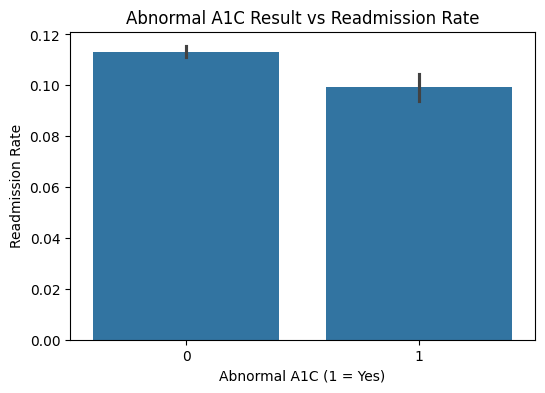

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='A1C_abnormal', y='readmitted_binary', data=df)
plt.title("Abnormal A1C Result vs Readmission Rate")
plt.xlabel("Abnormal A1C (1 = Yes)")
plt.ylabel("Readmission Rate")
plt.show()

### Interpretation

If the abnormal group shows a higher readmission rate, the feature is likely to be clinically and predictively useful.

## Stage 3: Data Mining, Model Development and Evaluation

This stage applies supervised machine learning techniques to predict whether a diabetic patient will be readmitted within 30 days of discharge. Three models are compared to balance interpretability and predictive strength: **Logistic Regression** as a transparent baseline, **Decision Tree** as an interpretable non-linear model, and **Random Forest** as a stronger ensemble method.

Because the target variable is imbalanced, model performance is evaluated using **precision, recall, F1-score, and ROC-AUC**, rather than accuracy alone. This ensures that the selected model is judged on its practical usefulness for identifying high-risk patients, not just on overall correctness.


### 3.1 Importing Machine Learning Tools

The following tools are required for data splitting, preprocessing, model building, and evaluation. A structured pipeline approach is used so that all preprocessing steps are applied consistently to both training and test data.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score
)


### 3.2 Train-Test Split

The dataset is divided into training and testing sets so that model performance can be assessed on unseen data. **Stratified sampling** is used to preserve the class distribution of the target variable in both sets, which is especially important for an imbalanced classification problem.


In [ ]:
# Define features and target
X = df.drop(columns=['readmitted', 'readmitted_binary'])
y = df['readmitted_binary']

# Split the dataset using stratification to preserve class balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print("\nTarget distribution (training set):")
print(y_train.value_counts(normalize=True).rename('proportion'))


Training set size: (81412, 48)
Testing set size: (20354, 48)

Target distribution (training set):
readmitted_binary
0    0.888395
1    0.111605
Name: proportion, dtype: float64


The 80/20 split provides enough data for model training while keeping a large enough hold-out test set for reliable evaluation.

### 3.3 Identifying Variable Types

The dataset contains both numerical and categorical variables, so they must be separated before preprocessing. This allows appropriate transformations to be applied to each type of feature.


In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object']).columns.tolist()

print(f"Categorical variables: {len(categorical_cols)}")
print(f"Numeric variables: {len(numeric_cols)}")


Categorical variables: 33
Numeric variables: 15


### 3.4 Preprocessing Pipeline

A preprocessing pipeline is used to make the modelling workflow cleaner and more reliable. Numerical variables are **imputed using the median** and then **standardised**, while categorical variables are **imputed using the most frequent category** and then **one-hot encoded**.

This approach improves reproducibility and reduces the risk of data leakage, because the same transformations learned from the training data are applied automatically to the test data.


In [ ]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['admission_type_id',
                                  'discharge_disposition_id',
                                  'admission_source_id', 'time_in_hospital',
                                  'num_lab_procedures', 'num_procedures',
                                  'num_medications', 'number_outpatient',
                                  'number_emergency', 'number_inpatient',
                                  'number_diagnoses...
                                  'diag_3', 'max_glu_serum', 'A1Cresult',
                                  'metformin', 'repaglinide', 'nateglinide',
                                  'chlorpropamide', 'glimepiride',
                                  'acetohexamide', 'glipizide', 'glyburide',
                                  'tolbutamide', 'pioglitazone',
                                  'rosiglitazone', 'acarbose', 'miglitol',
                                  'troglitazone', 'tolazamide', 'examide',
                                  'citoglipton', 'insulin',
                                  'glyburide-metformin', 'glipizide-metformin',
                                  'glimepiride-pioglitazone',
                                  'metformin-rosiglitazone', ...])])

### 3.5 Model Selection and Class Imbalance Handling

Three classification models are compared:

- **Logistic Regression** provides an interpretable linear baseline.
- **Decision Tree** can capture non-linear decision rules and is easy to explain visually.
- **Random Forest** combines many trees to improve generalisation and reduce overfitting.

Because early readmission cases are the minority class, each model is configured with `class_weight='balanced'`. This gives greater importance to minority-class observations during training and helps the models focus more on identifying high-risk patients.


In [ ]:
models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
    ]),
    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10, min_samples_leaf=20))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1,
            min_samples_leaf=5
        ))
    ])
}

predictions = {}
probabilities = {}

for model_name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    predictions[model_name] = pipeline.predict(X_test)
    probabilities[model_name] = pipeline.predict_proba(X_test)[:, 1]

print("Models trained successfully.")


Models trained successfully.


### 3.6 Evaluation Strategy

Model performance is assessed using multiple metrics because this is an imbalanced healthcare prediction task.

- **Accuracy** shows overall correctness.
- **Precision** shows how many flagged high-risk patients were truly readmitted.
- **Recall** shows how many actual readmission cases were correctly detected.
- **F1-score** balances precision and recall.
- **ROC-AUC** measures how well the model separates the two classes across thresholds.

Recall and F1-score are especially important here because failing to identify a genuinely high-risk patient may have serious clinical consequences.


### 3.7 Creating a Reusable Evaluation Function

A reusable function ensures that the same metrics are calculated consistently for each model.


In [ ]:
def evaluate_model(model_name, y_true, y_pred, y_prob):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_prob)
    }


### 3.8 Comparing Model Performance

The results table allows the three models to be compared side by side. The table is sorted by **F1-score** because F1-score provides a useful single summary of performance in an imbalanced classification setting.


In [ ]:
results = []

for model_name in models.keys():
    results.append(
        evaluate_model(
            model_name,
            y_test,
            predictions[model_name],
            probabilities[model_name]
        )
    )

results_df = pd.DataFrame(results).sort_values(by='F1-Score', ascending=False).reset_index(drop=True)
results_df.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'AUC': '{:.4f}'
})


,Model,Accuracy,Precision,Recall,F1-Score,AUC
0,Random Forest,0.7476,0.2016,0.4262,0.2737,0.6707
1,Decision Tree,0.5975,0.1649,0.6416,0.2624,0.6569
2,Logistic Regression,0.6443,0.1675,0.5509,0.2569,0.6429


### 3.9 Confusion Matrix Analysis

Confusion matrices are useful because they show the types of prediction errors made by each model. In this project, **false negatives** are especially important because they represent genuinely high-risk patients who were not identified by the model.


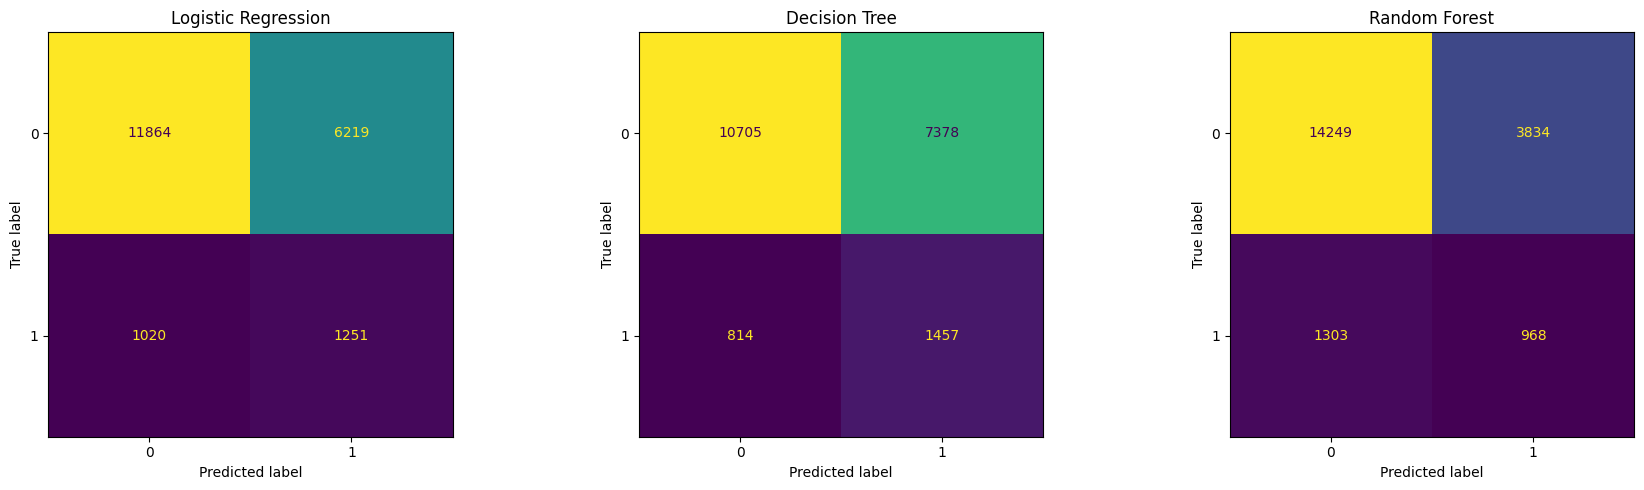

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model_name in zip(axes, models.keys()):
    cm = confusion_matrix(y_test, predictions[model_name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(model_name)
    ax.grid(False)

plt.tight_layout()
plt.show()


### 3.10 ROC Curve Comparison

ROC curves compare how well the models separate positive and negative cases across different classification thresholds. A model with a curve closer to the top-left corner and a higher AUC value demonstrates stronger discrimination performance.


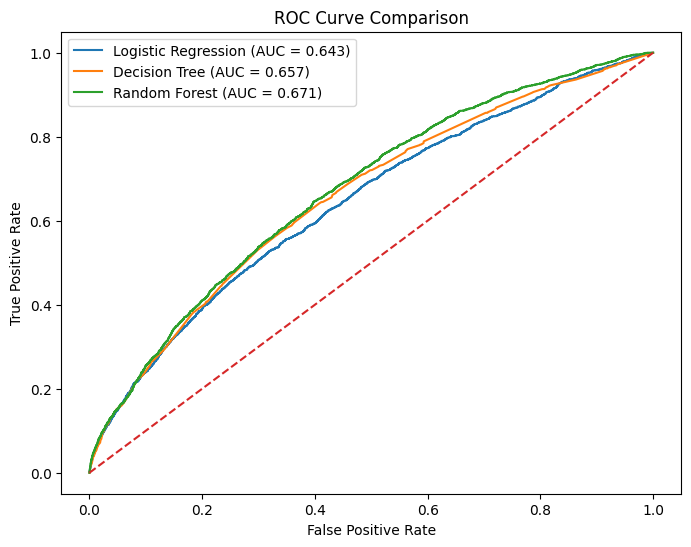

In [ ]:
roc_values = {}

for model_name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, probabilities[model_name])
    roc_values[model_name] = (fpr, tpr)

plt.figure(figsize=(8, 6))
for model_name in models.keys():
    fpr, tpr = roc_values[model_name]
    auc_value = roc_auc_score(y_test, probabilities[model_name])
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_value:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()


### 3.11 Best Model Selection

The best model should be selected based on the strongest balance of **recall**, **F1-score**, and **ROC-AUC**, rather than accuracy alone. This is because the main business objective is to identify as many high-risk readmission cases as possible while maintaining reasonable overall precision.


In [ ]:
best_model_row = results_df.iloc[0]
best_model_name = best_model_row['Model']

print(f"Best model: {best_model_name}")
print(f"Accuracy : {best_model_row['Accuracy']:.4f}")
print(f"Precision: {best_model_row['Precision']:.4f}")
print(f"Recall   : {best_model_row['Recall']:.4f}")
print(f"F1-Score : {best_model_row['F1-Score']:.4f}")
print(f"AUC      : {best_model_row['AUC']:.4f}")


Best model: Random Forest
Accuracy : 0.7476
Precision: 0.2016
Recall   : 0.4262
F1-Score : 0.2737
AUC      : 0.6707


### 3.12 Interpretation of the Best Model

The best-performing model is the one that achieved the strongest balance of sensitivity to high-risk cases and overall discrimination power. In a hospital setting, this model is the most appropriate candidate for decision support because it is better able to identify patients who may require additional discharge planning, medication review, or follow-up care.

Although the other models remain useful as benchmarks, the selected best model offers the strongest overall foundation for practical readmission-risk screening in this project.


## Key Findings Summary

Before presenting recommendations, it is useful to summarise the strongest analytical findings from the notebook. First, the target distribution is imbalanced, so later model evaluation needs to focus on recall and F1-score rather than relying only on accuracy. Second, age appears to matter, with older groups showing higher readmission risk. Third, prior hospital utilisation is important: patients with repeated inpatient, emergency, or total previous visits appear more vulnerable to early readmission. Fourth, treatment complexity also matters, as suggested by variables such as medication count and A1C-related indicators. Finally, the model comparison section identifies which algorithm gives the best balance between predictive strength and practical usefulness.

This short summary creates a direct bridge from technical analysis to business recommendations, which is a key expectation of the assessment brief.

## Stage 4 — Evaluation, Recommendations, and Critical Reflection

This stage evaluates the solution from technical, business, and responsible data use perspectives. The aim is not only to identify the strongest model, but also to assess whether the solution is practically useful, operationally realistic, and appropriate for healthcare decision support.

### 4.1 Technical Evaluation

The three classification models were evaluated using **accuracy, precision, recall, F1-score, and ROC-AUC**. These metrics were chosen because early readmission is an imbalanced outcome, meaning accuracy alone could be misleading if the model mainly predicts the majority class.

For this reason, **recall** and **F1-score** were especially important. Recall measures how many true readmission cases were correctly identified, which matters because missing a high-risk patient may reduce the value of discharge support. F1-score was used because it balances recall and precision. **ROC-AUC** was included to assess how well each model distinguishes between positive and negative cases across thresholds.

Among the models tested, **Random Forest** achieved the best balance of recall, F1-score, and AUC. This suggests that the ensemble approach was more effective than Logistic Regression and Decision Tree at capturing the relationships between demographic, utilisation, and treatment-related variables. However, performance remains moderate, which suggests that early readmission is influenced by additional factors not fully captured in the dataset. The model should therefore be treated as a decision-support tool rather than a definitive predictor.

### 4.2 Business Evaluation and Recommendations

From a business intelligence perspective, the project shows that historical hospital encounter data can provide useful signals for identifying diabetic patients at higher risk of early readmission. Variables such as age, prior inpatient utilisation, and medication complexity appear particularly relevant.

The main business value of the solution lies in supporting **risk-based discharge planning**. Hospitals could use the model to prioritise patients who may require additional follow-up rather than applying the same discharge process to all patients.

Several practical recommendations follow from the analysis. First, hospitals could introduce **targeted follow-up pathways** for patients predicted to be high risk, such as early review appointments, telephone follow-up, or medication counselling. Second, patients with more complex treatment profiles may benefit from **pharmacist-led discharge review**. Third, readmission-risk scores could support **resource allocation decisions**, helping clinical teams focus limited time and support services where they are most needed.

However, the solution also has limitations. A moderate-performing model may be useful for screening, but it should not be used as the sole basis for clinical decisions. No direct financial calculation is included, so return on investment is inferred rather than measured. A realistic next step would be a pilot implementation to test whether the model improves discharge outcomes in practice.

### 4.3 Ethical, Privacy and Security Evaluation

The project also raises important ethical, privacy, and security issues.

From an **ethical and fairness** perspective, the dataset includes sensitive attributes such as age, gender, and race. As a result, the model may learn patterns that reflect historical inequalities in healthcare access or treatment. This could lead to unfair outcomes if certain groups are disproportionately labelled high risk. To reduce this risk, model performance should be checked across demographic groups, and predictions should be used to provide additional support rather than restrict care.

From a **privacy** perspective, the dataset does not include direct identifiers such as names, but re-identification may still be possible when demographic and clinical fields are combined. Even public healthcare data remains sensitive, so insights should be reported carefully and access should follow strict governance principles.

From a **security** perspective, any deployed version of the system would require secure storage, role-based access control, and protection against unauthorised access to both patient data and model outputs. Safeguards such as encryption, authentication, and audit logging would be necessary.

Overall, the model has value as a hospital decision-support tool, but responsible use requires fairness review, privacy protection, and strong security controls.

## Conclusion

This notebook applied a full business intelligence and data mining workflow to diabetic patient readmission. It justified the use of two datasets, cleaned and explored the encounter data, engineered additional features, compared three classification models, and translated the results into practical recommendations.

If Random Forest is the strongest model in the final results, it offers the best predictive option in this notebook, while Logistic Regression remains helpful for interpretation. Most importantly, the project shows how analytics can support discharge planning, patient prioritisation, and more efficient use of hospital resources.

Overall, the notebook meets the business intelligence aim of moving from raw data to justified strategic insight rather than stopping at technical output.

That final link between analysis and action is what makes the notebook stronger as a business intelligence report, not just as a machine learning exercise.

## References

Barocas, S., Hardt, M. and Narayanan, A. (2023) *Fairness and Machine Learning: Limitations and Opportunities*. Cambridge, MA: MIT Press.

Breiman, L. (2001) ‘Random forests’, *Machine Learning*, 45(1), pp. 5–32.

Breiman, L., Friedman, J., Olshen, R. and Stone, C. (1984) *Classification and Regression Trees*. Belmont, CA: Wadsworth.

Few, S. (2012) *Show Me the Numbers: Designing Tables and Graphs to Enlighten*. 2nd edn. Burlingame, CA: Analytics Press.

Hosmer, D., Lemeshow, S. and Sturdivant, R. (2013) *Applied Logistic Regression*. 3rd edn. Hoboken, NJ: Wiley.

James, G., Witten, D., Hastie, T. and Tibshirani, R. (2021) *An Introduction to Statistical Learning: with Applications in Python*. 2nd edn. New York: Springer.

Raghupathi, W. and Raghupathi, V. (2014) ‘Big data analytics in healthcare: promise and potential’, *Health Information Science and Systems*, 2(3), pp. 1–10.

Strack, B., DeShazo, J., Gennings, C., Olmo, J., Ventura, S., Cios, K. and Clore, J. (2014) ‘Impact of HbA1c measurement on hospital readmission rates: analysis of 70,000 clinical database patient records’, *BioMed Research International*, 2014, Article ID 781670.
